In [1]:
import numpy as np
from Bio.PDB import PDBParser
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr
from sklearn.manifold import MDS

import numpy as np
import matplotlib.pyplot as plt
import os
print(os.getpid())

526647


In [2]:
#option 1


import numpy as np
from Bio.PDB import PDBParser, Polypeptide
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize


# ---------------------------------------------------------------------
# 1) Reproduce the same filtered residue order as mapPDBToHMM
# ---------------------------------------------------------------------
def get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds):
    """
    Rebuilds the residue list in the same spirit/order as mapPDBToHMM.
    Assumes chainIds is a string like 'A' or 'AB'.
    """
    chainIds = list(chainIds)
    structure = PDBParser(QUIET=True).get_structure('void', pdbFile)

    chains = structure[0].get_chains()
    residues = [chain.get_list() for chain in chains if chain.id in chainIds]
    residues = [res for resList in residues for res in resList]

    filtered_residues = []
    filtered_seq = []

    for res in residues:
        if Polypeptide.is_aa(res, standard=True):
            try:
                aa = Polypeptide.protein_letters_3to1[res.get_resname()]
            except Exception:
                continue
            filtered_residues.append(res)
            filtered_seq.append(aa)

    if len(filtered_residues) == 0:
        raise ValueError(f"No standard amino-acid residues found on chains {chainIds}")

    return filtered_residues, ''.join(filtered_seq)


# ---------------------------------------------------------------------
# 2) Representative coordinate per residue
# ---------------------------------------------------------------------
def residue_rep_coord(res, distType='all'):
    """
    distType:
      - 'all'   -> centroid of all atoms in the residue
      - 'alpha' -> CA
      - 'beta'  -> CB, or CA for GLY
    """
    if distType == 'alpha':
        if "CA" in res:
            return res["CA"].get_coord()
        # fallback
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    if distType == 'beta':
        if res.get_resname() == 'GLY':
            if "CA" in res:
                return res["CA"].get_coord()
        else:
            if "CB" in res:
                return res["CB"].get_coord()
        # fallback
        if "CA" in res:
            return res["CA"].get_coord()
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    # distType == 'all'
    atoms = [a.get_coord() for a in res.get_atoms()]
    return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])


def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    """
    Builds an array of shape (len(mi), 3), with NaN for gaps/unmapped positions.
    Your code suggests:
      - mi == -1 => gap
      - positive values are 1-based residue indices in the filtered residue list
    """
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1   # matches your current convention
    idx = mi[valid] - 1
    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq


# ---------------------------------------------------------------------
# 3) Classical MDS initialization
# ---------------------------------------------------------------------
def classical_mds(D, n_components=3):
    """
    Classical MDS for a complete distance matrix.
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    vals = np.maximum(evals[:n_components], 0.0)
    X = evecs[:, :n_components] * np.sqrt(vals)
    return X


def initial_fill_for_mds(D):
    """
    Fill missing distances for a good initial guess.
    """
    D = np.asarray(D, dtype=float)
    out = D.copy()

    finite = np.isfinite(out)
    finite_vals = out[finite & ~np.eye(out.shape[0], dtype=bool)]
    if finite_vals.size == 0:
        raise ValueError("No finite distances available for reconstruction.")

    fill_value = np.median(finite_vals) * 1.5
    out[~np.isfinite(out)] = fill_value
    out = 0.5 * (out + out.T)
    np.fill_diagonal(out, 0.0)
    return out


# ---------------------------------------------------------------------
# 4) Reconstruction by stress minimization over observed pairs
# ---------------------------------------------------------------------
def reconstruct_3d_from_partial_distance_matrix(D, random_state=0, maxiter=800):
    """
    Reconstruct coordinates from a distance matrix that may contain inf entries.
    We minimize stress only over finite pairs.

    Returns:
        X: (N,3) coordinates
        stress: final MSE over observed pairs
        success: optimizer success flag
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D0 = initial_fill_for_mds(D)
    X0 = classical_mds(D0, n_components=3)

    iu = np.triu_indices(n, k=1)
    obs = np.isfinite(D[iu])
    i_idx = iu[0][obs]
    j_idx = iu[1][obs]
    target = D[i_idx, j_idx]

    def objective(x_flat):
        X = x_flat.reshape(n, 3)
        d = np.linalg.norm(X[i_idx] - X[j_idx], axis=1)
        return np.mean((d - target) ** 2)

    res = minimize(
        objective,
        X0.ravel(),
        method='L-BFGS-B',
        options={'maxiter': maxiter, 'ftol': 1e-10}
    )

    X = res.x.reshape(n, 3)
    return X, float(res.fun), bool(res.success)


# ---------------------------------------------------------------------
# 5) Alignment and comparison to PDB coordinates
# ---------------------------------------------------------------------

def kabsch_align(P, Q):
    """
    Align P onto Q with optimal rotation after centering.
    Returns aligned P, centered Q, RMSD.
    """
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt

    P_aligned = Pc @ R
    rmsd_val = np.sqrt(np.mean(np.sum((P_aligned - Qc) ** 2, axis=1)))
    return P_aligned, Qc, rmsd_val

def best_alignment_with_mirror(P, Q):
    """
    Distance maps cannot distinguish mirror images.
    Try both orientations and keep the better one.
    """
    P1, Qc1, r1 = kabsch_align(P, Q)

    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2 = kabsch_align(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, "mirrored"
    return P1, Qc1, r1, "normal"

#if i want scaling
def optimal_scaling(P, Q):
    """
    Find scalar s minimizing ||sP - Q||^2
    """
    num = np.sum(P * Q)
    den = np.sum(P * P)
    return num / den

def align_with_scaling(P, Q):
    """
    Align P onto Q with rotation + scaling
    """
    # center
    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    # rotation (Kabsch)
    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1, 1, d]) @ Wt

    P_rot = Pc @ R

    # scaling
    s = optimal_scaling(P_rot, Qc)
    P_scaled = s * P_rot

    rmsd = np.sqrt(np.mean(np.sum((P_scaled - Qc)**2, axis=1)))

    return P_scaled, Qc, rmsd, s


def best_alignment_with_scaling_and_mirror(P, Q):
    # normal
    P1, Qc1, r1, s1 = align_with_scaling(P, Q)

    # mirrored
    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2, s2 = align_with_scaling(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, s2, "mirrored"
    else:
        return P1, Qc1, r1, s1, "normal"



def distance_metrics(D_true, D_pred):
    """
    Compare two complete distance matrices on the upper triangle.
    """
    iu = np.triu_indices_from(D_true, k=1)
    a = D_true[iu]
    b = D_pred[iu]

    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    pearson = np.corrcoef(a, b)[0, 1] if len(a) > 1 else np.nan
    mae = np.mean(np.abs(a - b)) if len(a) else np.nan
    rmse = np.sqrt(np.mean((a - b) ** 2)) if len(a) else np.nan

    return {"pearson": pearson, "mae": mae, "rmse": rmse}


# ---------------------------------------------------------------------
# 6) End-to-end pipeline
# ---------------------------------------------------------------------
def reconstruct_and_compare_with_mapPDBToHMM(dm, mi, pdbFile, chainIds, distType='all'):
    """
    dm: output distance map from mapPDBToHMM
    mi: mapping indexes from mapPDBToHMM
    distType: must match the way the map was constructed
    """
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # Use only residues that are mapped and have enough finite constraints
    valid = (mi >= 1) & (np.isfinite(dm).sum(axis=1) > 1)

    if valid.sum() < 4:
        raise ValueError("Too few mapped residues with finite distances to reconstruct 3D.")

    D_obs = dm[np.ix_(valid, valid)]

    # Reconstruct 3D from the observed map
    X_rec, stress, success = reconstruct_3d_from_partial_distance_matrix(D_obs)

    # Build PDB reference coordinates in the same order
    # For distType='all', centroid is the most reasonable comparison point.
    ref_coords_full, residues, seq = extract_reference_coords_from_mi(
        pdbFile, chainIds, mi, distType=distType
    )
    X_ref = ref_coords_full[valid]

    # Align reconstruction to the PDB reference
    X_aligned, X_ref_centered, coord_rmsd, scale, orientation = best_alignment_with_scaling_and_mirror(X_rec, X_ref)

    print("Scale factor:", scale)

    # Distance consistency of reconstructed 3D against observed dm
    D_rec = squareform(pdist(X_rec))
    dm_stats = distance_metrics(D_obs, D_rec)

    return {
        "X_rec": X_rec,
        "X_aligned": X_aligned,
        "X_ref_centered": X_ref_centered,
        "valid_mask": valid,
        "stress": stress,
        "optimizer_success": success,
        "coord_rmsd": coord_rmsd,
        "orientation": orientation,
        "distance_metrics": dm_stats,
        "D_obs": D_obs,
        "D_rec": D_rec,
    }

#plot

def plot_3d_overlay(X_ref, X_rec_aligned, title="3D comparison"):
    """
    X_ref: reference coordinates (from PDB, centered)
    X_rec_aligned: reconstructed coordinates aligned to reference
    """

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot PDB reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB",
        linewidth=2
    )

    # Plot reconstructed
    ax.plot(
        X_rec_aligned[:, 0], X_rec_aligned[:, 1], X_rec_aligned[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optionally connect corresponding residues (helps visually)
    for i in range(len(X_ref)):
        ax.plot(
            [X_ref[i, 0], X_rec_aligned[i, 0]],
            [X_ref[i, 1], X_rec_aligned[i, 1]],
            [X_ref[i, 2], X_rec_aligned[i, 2]],
            alpha=0.2
        )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_error_per_residue(X_ref, X_rec):
    errors = np.linalg.norm(X_ref - X_rec, axis=1)

    plt.figure(figsize=(7, 3))
    plt.plot(errors)
    plt.xlabel("Residue index")
    plt.ylabel("Distance error")
    plt.title("Per-residue reconstruction error")
    plt.tight_layout()
    plt.show()


def save_coords_as_pdb(coords, filename="reconstructed.pdb", chain_id="A"):
    """
    Save coordinates as a fake CA-only PDB for visualization.
    """
    with open(filename, "w") as f:
        for i, (x, y, z) in enumerate(coords, start=1):
            f.write(
                f"ATOM  {i:5d}  CA  ALA {chain_id}{i:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n"
            )
        f.write("END\n")

In [ ]:
#option2


import numpy as np
from Bio.PDB import PDBParser, Polypeptide
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize


# ---------------------------------------------------------------------
# 1) Reproduce the same filtered residue order as mapPDBToHMM
# ---------------------------------------------------------------------
def get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds):
    """
    Rebuilds the residue list in the same spirit/order as mapPDBToHMM.
    Assumes chainIds is a string like 'A' or 'AB'.
    """
    chainIds = list(chainIds)
    structure = PDBParser(QUIET=True).get_structure('void', pdbFile)

    chains = structure[0].get_chains()
    residues = [chain.get_list() for chain in chains if chain.id in chainIds]
    residues = [res for resList in residues for res in resList]

    filtered_residues = []
    filtered_seq = []

    for res in residues:
        if Polypeptide.is_aa(res, standard=True):
            try:
                aa = Polypeptide.protein_letters_3to1[res.get_resname()]
            except Exception:
                continue
            filtered_residues.append(res)
            filtered_seq.append(aa)

    if len(filtered_residues) == 0:
        raise ValueError(f"No standard amino-acid residues found on chains {chainIds}")

    return filtered_residues, ''.join(filtered_seq)


# ---------------------------------------------------------------------
# 2) Representative coordinate per residue
# ---------------------------------------------------------------------
def residue_rep_coord(res, distType='all'):
    """
    distType:
      - 'all'   -> centroid of all atoms in the residue
      - 'alpha' -> CA
      - 'beta'  -> CB, or CA for GLY
    """
    if distType == 'alpha':
        if "CA" in res:
            return res["CA"].get_coord()
        # fallback
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    if distType == 'beta':
        if res.get_resname() == 'GLY':
            if "CA" in res:
                return res["CA"].get_coord()
        else:
            if "CB" in res:
                return res["CB"].get_coord()
        # fallback
        if "CA" in res:
            return res["CA"].get_coord()
        atoms = [a.get_coord() for a in res.get_atoms()]
        return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])

    # distType == 'all'
    atoms = [a.get_coord() for a in res.get_atoms()]
    return np.mean(atoms, axis=0) if atoms else np.array([np.nan, np.nan, np.nan])


def extract_reference_coords_from_mi(pdbFile, chainIds, mi, distType='all'):
    """
    Builds an array of shape (len(mi), 3), with NaN for gaps/unmapped positions.
    Your code suggests:
      - mi == -1 => gap
      - positive values are 1-based residue indices in the filtered residue list
    """
    residues, seq = get_filtered_residues_like_mapPDBToHMM(pdbFile, chainIds)
    rep_coords = np.asarray([residue_rep_coord(res, distType=distType) for res in residues], dtype=float)

    mi = np.asarray(mi, dtype=int)
    coords_full = np.full((len(mi), 3), np.nan, dtype=float)

    valid = mi >= 1   # matches your current convention
    idx = mi[valid] - 1
    if np.any(idx < 0) or np.any(idx >= len(rep_coords)):
        raise ValueError("mi contains indices outside the filtered residue list.")

    coords_full[valid] = rep_coords[idx]
    return coords_full, residues, seq


#preprocess distance matrix 

def preprocess_distance_matrix(D, q=0.98):
    """
    Symmetrize, remove infinities, and clip extreme values.
    """
    D = np.asarray(D, dtype=float)
    D = 0.5 * (D + D.T)
    np.fill_diagonal(D, 0.0)

    finite = np.isfinite(D) & (D > 0)
    vals = D[finite]

    if vals.size == 0:
        raise ValueError("No finite distances in matrix.")

    fill_value = np.median(vals)
    upper = np.quantile(vals, q)

    D2 = D.copy()
    D2[~np.isfinite(D2)] = fill_value
    D2 = np.clip(D2, 0.0, upper)

    return D2



# ---------------------------------------------------------------------
# 3) Classical MDS initialization
# ---------------------------------------------------------------------
def classical_mds(D, n_components=3):
    """
    Classical MDS for a complete distance matrix.
    """
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    vals = np.maximum(evals[:n_components], 0.0)
    X = evecs[:, :n_components] * np.sqrt(vals)
    return X



# ---------------------------------------------------------------------
# 4) Reconstruction by stress minimization over observed pairs
# ---------------------------------------------------------------------
def huber_loss(r, delta=1.0):
    """
    Robust loss for residuals.
    """
    a = np.abs(r)
    return np.where(a <= delta, 0.5 * r * r, delta * (a - 0.5 * delta))


def robust_reconstruct_3d(
    D,
    ignore_band=2,
    chain_lambda=0.1,
    smooth_lambda=0.02,
    n_restarts=10,
    maxiter=1000,
    random_state=0,
):
    """
    Reconstruct 3D coordinates from a noisy distance matrix.

    ignore_band:
        ignore pairs with |i-j| <= ignore_band in the distance fit
        and let the smoothness prior handle local geometry.

    chain_lambda:
        soft penalty on consecutive residues staying too far apart.

    smooth_lambda:
        soft penalty on curvature of the chain.

    Returns:
        best_X, best_stress
    """
    rng = np.random.default_rng(random_state)
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    # Fit only finite, nonlocal pairs
    iu = np.triu_indices(n, k=1)
    mask_finite = np.isfinite(D[iu])
    ii = iu[0][mask_finite]
    jj = iu[1][mask_finite]

    nonlocal_mask = np.abs(ii - jj) > ignore_band
    ii = ii[nonlocal_mask]
    jj = jj[nonlocal_mask]
    targets = D[ii, jj]

    if len(targets) < 3:
        raise ValueError("Too few usable distance constraints.")

    # Local chain target estimated from the matrix itself
    chain_vals = [D[i, i + 1] for i in range(n - 1) if np.isfinite(D[i, i + 1])]
    if len(chain_vals) > 0:
        chain_target = float(np.median(chain_vals))
    else:
        chain_target = float(np.median(targets))

    # Initial guess from filled matrix
    D0 = preprocess_distance_matrix(D)
    X0 = classical_mds(D0)

    def objective(x_flat):
        X = x_flat.reshape(n, 3)

        # fit observed nonlocal distances
        d_obs = np.linalg.norm(X[ii] - X[jj], axis=1)
        resid = d_obs - targets
        stress_data = np.mean(huber_loss(resid, delta=1.0))

        # weak chain continuity prior
        if n > 1:
            d_chain = np.linalg.norm(X[1:] - X[:-1], axis=1)
            stress_chain = np.mean(huber_loss(d_chain - chain_target, delta=1.0))
        else:
            stress_chain = 0.0

        # smoothness prior: avoid jagged backbone
        if n > 2:
            second_diff = X[2:] - 2 * X[1:-1] + X[:-2]
            stress_smooth = np.mean(np.sum(second_diff ** 2, axis=1))
        else:
            stress_smooth = 0.0

        return stress_data + chain_lambda * stress_chain + smooth_lambda * stress_smooth

    best_X = None
    best_fun = np.inf

    for _ in range(n_restarts):
        x_init = X0 + 0.05 * rng.standard_normal(X0.shape)
        res = minimize(
            objective,
            x_init.ravel(),
            method="L-BFGS-B",
            options={"maxiter": maxiter, "ftol": 1e-10},
        )

        if res.fun < best_fun:
            best_fun = res.fun
            best_X = res.x.reshape(n, 3)

    return best_X, best_fun


# ---------------------------------------------------------------------
# 5) Alignment and comparison to PDB coordinates
# ---------------------------------------------------------------------

def kabsch_align(P, Q):
    """
    Align P onto Q with optimal rotation after centering.
    Returns aligned P, centered Q, RMSD.
    """
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1.0, 1.0, d]) @ Wt

    P_aligned = Pc @ R
    rmsd_val = np.sqrt(np.mean(np.sum((P_aligned - Qc) ** 2, axis=1)))
    return P_aligned, Qc, rmsd_val

def best_alignment_with_mirror(P, Q):
    """
    Distance maps cannot distinguish mirror images.
    Try both orientations and keep the better one.
    """
    P1, Qc1, r1 = kabsch_align(P, Q)

    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2 = kabsch_align(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, "mirrored"
    return P1, Qc1, r1, "normal"

#if i want scaling
def optimal_scaling(P, Q):
    """
    Find scalar s minimizing ||sP - Q||^2
    """
    num = np.sum(P * Q)
    den = np.sum(P * P)
    return num / den

def align_with_scaling(P, Q):
    """
    Align P onto Q with rotation + scaling
    """
    # center
    Pc = P - P.mean(axis=0)
    Qc = Q - Q.mean(axis=0)

    # rotation (Kabsch)
    C = Pc.T @ Qc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    R = V @ np.diag([1, 1, d]) @ Wt

    P_rot = Pc @ R

    # scaling
    s = optimal_scaling(P_rot, Qc)
    P_scaled = s * P_rot

    rmsd = np.sqrt(np.mean(np.sum((P_scaled - Qc)**2, axis=1)))

    return P_scaled, Qc, rmsd, s


def best_alignment_with_scaling_and_mirror(P, Q):
    # normal
    P1, Qc1, r1, s1 = align_with_scaling(P, Q)

    # mirrored
    Pm = P.copy()
    Pm[:, 0] *= -1
    P2, Qc2, r2, s2 = align_with_scaling(Pm, Q)

    if r2 < r1:
        return P2, Qc2, r2, s2, "mirrored"
    else:
        return P1, Qc1, r1, s1, "normal"



def distance_metrics(D_true, D_pred):
    """
    Compare two complete distance matrices on the upper triangle.
    """
    iu = np.triu_indices_from(D_true, k=1)
    a = D_true[iu]
    b = D_pred[iu]

    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    pearson = np.corrcoef(a, b)[0, 1] if len(a) > 1 else np.nan
    mae = np.mean(np.abs(a - b)) if len(a) else np.nan
    rmse = np.sqrt(np.mean((a - b) ** 2)) if len(a) else np.nan

    return {"pearson": pearson, "mae": mae, "rmse": rmse}


# ---------------------------------------------------------------------
# 6) End-to-end pipeline
# ---------------------------------------------------------------------
def reconstruct_and_compare_with_mapPDBToHMM(dm, mi, pdbFile, chainIds, distType='all'):
    """
    dm: output distance map from mapPDBToHMM
    mi: mapping indexes from mapPDBToHMM
    distType: must match the way the map was constructed
    """
    dm = np.asarray(dm, dtype=float)
    mi = np.asarray(mi, dtype=int)

    # Use only residues that are mapped and have enough finite constraints
    valid = (mi >= 1) & (np.isfinite(dm).sum(axis=1) > 1)

    if valid.sum() < 4:
        raise ValueError("Too few mapped residues with finite distances to reconstruct 3D.")

    D_obs = dm[np.ix_(valid, valid)]

    D_clean = preprocess_distance_matrix(D_obs)
    # Reconstruct 3D from the observed map
    X_rec, stress = robust_reconstruct_3d(
    D_clean,
    ignore_band=2,
    chain_lambda=0.1,
    smooth_lambda=0.02,
    n_restarts=20,
    maxiter=1500,
)
    # Build PDB reference coordinates in the same order
    # For distType='all', centroid is the most reasonable comparison point.
    ref_coords_full, residues, seq = extract_reference_coords_from_mi(
        pdbFile, chainIds, mi, distType=distType
    )
    X_ref = ref_coords_full[valid]

    # Align reconstruction to the PDB reference
    X_aligned, X_ref_centered, coord_rmsd, scale, orientation = best_alignment_with_scaling_and_mirror(X_rec, X_ref)

    print("Scale factor:", scale)

    # Distance consistency of reconstructed 3D against observed dm
    D_rec = squareform(pdist(X_rec))
    dm_stats = distance_metrics(D_obs, D_rec)

    return {
        "X_rec": X_rec,
        "X_aligned": X_aligned,
        "X_ref_centered": X_ref_centered,
        "valid_mask": valid,
        "stress": stress,
        "coord_rmsd": coord_rmsd,
        "orientation": orientation,
        "distance_metrics": dm_stats,
        "D_obs": D_obs,
        "D_rec": D_rec,
    }


#plot

def plot_3d_overlay(X_ref, X_rec_aligned, title="3D comparison"):
    """
    X_ref: reference coordinates (from PDB, centered)
    X_rec_aligned: reconstructed coordinates aligned to reference
    """

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot PDB reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB",
        linewidth=2
    )

    # Plot reconstructed
    ax.plot(
        X_rec_aligned[:, 0], X_rec_aligned[:, 1], X_rec_aligned[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optionally connect corresponding residues (helps visually)
    for i in range(len(X_ref)):
        ax.plot(
            [X_ref[i, 0], X_rec_aligned[i, 0]],
            [X_ref[i, 1], X_rec_aligned[i, 1]],
            [X_ref[i, 2], X_rec_aligned[i, 2]],
            alpha=0.2
        )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_error_per_residue(X_ref, X_rec):
    errors = np.linalg.norm(X_ref - X_rec, axis=1)

    plt.figure(figsize=(7, 3))
    plt.plot(errors)
    plt.xlabel("Residue index")
    plt.ylabel("Distance error")
    plt.title("Per-residue reconstruction error")
    plt.tight_layout()
    plt.show()


def save_coords_as_pdb(coords, filename="reconstructed.pdb", chain_id="A"):
    """
    Save coordinates as a fake CA-only PDB for visualization.
    """
    with open(filename, "w") as f:
        for i, (x, y, z) in enumerate(coords, start=1):
            f.write(
                f"ATOM  {i:5d}  CA  ALA {chain_id}{i:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n"
            )
        f.write("END\n")


In [19]:
from sequenceHandler import mapPDBToHMM
pfam_id= "PF00013"
pdb_file = f"PDB/{pfam_id}.pdb"
chain_id = "A"
hmm_file = f"HMM/{pfam_id}.hmm"
hmm_file_2 = "None"        
output_map_file = "None"  


dm, mi, aligned_sequence = mapPDBToHMM(pdb_file, chain_id, hmm_file, hmm_file_2, output_map_file, distType='alpha')
result = reconstruct_and_compare_with_mapPDBToHMM(dm, mi, pdb_file, chain_id, distType='alpha')
print(result["stress"], result["coord_rmsd"], result["distance_metrics"])

Scale factor: 0.9461746342510624
8.703722213785206e-29 3.652007622652984 {'pearson': np.float64(1.0), 'mae': np.float64(6.1619197904441474e-15), 'rmse': np.float64(9.329374155743356e-15)}


In [20]:
import matplotlib.pyplot as plt


def plot_3d_overlay(X_ref, X_rec_aligned, title="3D comparison"):
    """
    X_ref: reference coordinates (from PDB, centered)
    X_rec_aligned: reconstructed coordinates aligned to reference
    """

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot PDB reference
    ax.plot(
        X_ref[:, 0], X_ref[:, 1], X_ref[:, 2],
        label="PDB",
        linewidth=2
    )

    # Plot reconstructed
    ax.plot(
        X_rec_aligned[:, 0], X_rec_aligned[:, 1], X_rec_aligned[:, 2],
        linestyle='--',
        label="Reconstruction",
        linewidth=2
    )

    # Optionally connect corresponding residues (helps visually)
    for i in range(len(X_ref)):
        ax.plot(
            [X_ref[i, 0], X_rec_aligned[i, 0]],
            [X_ref[i, 1], X_rec_aligned[i, 1]],
            [X_ref[i, 2], X_rec_aligned[i, 2]],
            alpha=0.2
        )

    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()



Scale factor: 0.9461746342510624


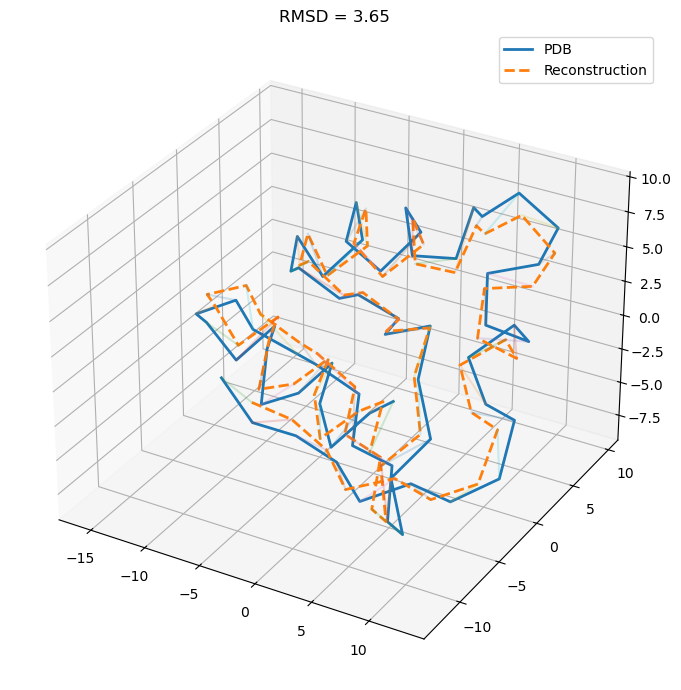

In [21]:
result = reconstruct_and_compare_with_mapPDBToHMM(
    dm, mi, pdb_file, chain_id, distType='alpha'
)

plot_3d_overlay(
    result["X_ref_centered"],
    result["X_aligned"],
    title=f"RMSD = {result['coord_rmsd']:.2f}"
)

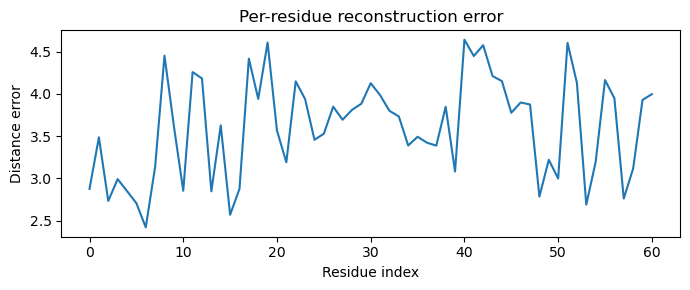

In [22]:
def plot_error_per_residue(X_ref, X_rec):
    errors = np.linalg.norm(X_ref - X_rec, axis=1)

    plt.figure(figsize=(7, 3))
    plt.plot(errors)
    plt.xlabel("Residue index")
    plt.ylabel("Distance error")
    plt.title("Per-residue reconstruction error")
    plt.tight_layout()
    plt.show()

plot_error_per_residue(
    result["X_ref_centered"],
    result["X_aligned"])

In [23]:
def save_coords_as_pdb(coords, filename="reconstructed.pdb", chain_id="A"):
    """
    Save coordinates as a fake CA-only PDB for visualization.
    """
    with open(filename, "w") as f:
        for i, (x, y, z) in enumerate(coords, start=1):
            f.write(
                f"ATOM  {i:5d}  CA  ALA {chain_id}{i:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00           C\n"
            )
        f.write("END\n")

# Save reconstructed (aligned)
save_coords_as_pdb(result["X_aligned"], "reconstructed.pdb")

# Save reference
save_coords_as_pdb(result["X_ref_centered"], "reference.pdb")